# Library Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Dataset Load & Preprocess

In [2]:
# ── Manual .npz file থেকে load ──
data = np.load(r'F:\B.Sc Engineering in ICE\All Lab\Neural Networks Sessional\mnist.npz')

X_train = data['x_train']
y_train = data['y_train']

# Normalize to [-1, 1]
X_train = (X_train.astype('float32') - 127.5) / 127.5
X_train = X_train.reshape(-1, 28, 28, 1)

print("Dataset shape:", X_train.shape)

Dataset shape: (60000, 28, 28, 1)


# Generator Model

In [3]:
def build_generator():
    model = models.Sequential([
        # random noise (100,) → 7x7x256 feature map
        layers.Dense(7*7*256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),

        # upsample → 14x14
        layers.Conv2DTranspose(128, (5,5), strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # upsample → 28x28
        layers.Conv2DTranspose(64, (5,5), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # final output — 28x28x1, tanh → [-1,1]
        layers.Conv2DTranspose(1, (5,5), strides=2, padding='same',
                               use_bias=False, activation='tanh')
    ])
    return model

generator = build_generator()
generator.summary()

c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

# Discriminator Model

In [4]:
def build_discriminator():
    model = models.Sequential([
        # real/fake image 28x28x1 → feature extraction
        layers.Conv2D(64, (5,5), strides=2, padding='same', input_shape=(28,28,1)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5,5), strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)  # real=1, fake=0 (no sigmoid — handled in loss)
    ])
    return model

discriminator = build_discriminator()
discriminator.summary()

c:\Users\User\anaconda3\envs\uzzal\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

# Loss & Optimizers

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    # Generator চায় Discriminator fake কে real ভাবুক
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer  = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

# Training Step

In [6]:
NOISE_DIM  = 100
BATCH_SIZE = 256
EPOCHS     = 50

@tf.function  # faster execution
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    # Gradient update
    gen_grads  = gen_tape.gradient(g_loss,  generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads,  generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return g_loss, d_loss

#  Train GAN

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(60000).batch(BATCH_SIZE)

g_losses, d_losses = [], []

for epoch in range(EPOCHS):
    for batch in dataset:
        g_loss, d_loss = train_step(batch)

    g_losses.append(g_loss.numpy())
    d_losses.append(d_loss.numpy())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | G Loss: {g_loss:.4f} | D Loss: {d_loss:.4f}")

# Loss Curve

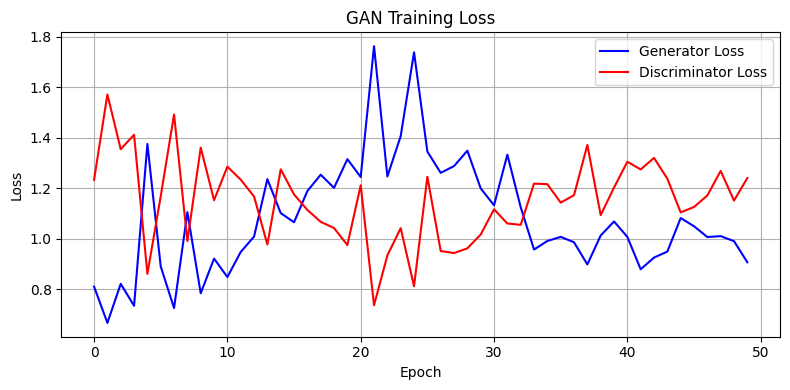

In [37]:
plt.figure(figsize=(8, 4))
plt.plot(g_losses, 'b-', label='Generator Loss')
plt.plot(d_losses, 'r-', label='Discriminator Loss')
plt.title('GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Generated Images

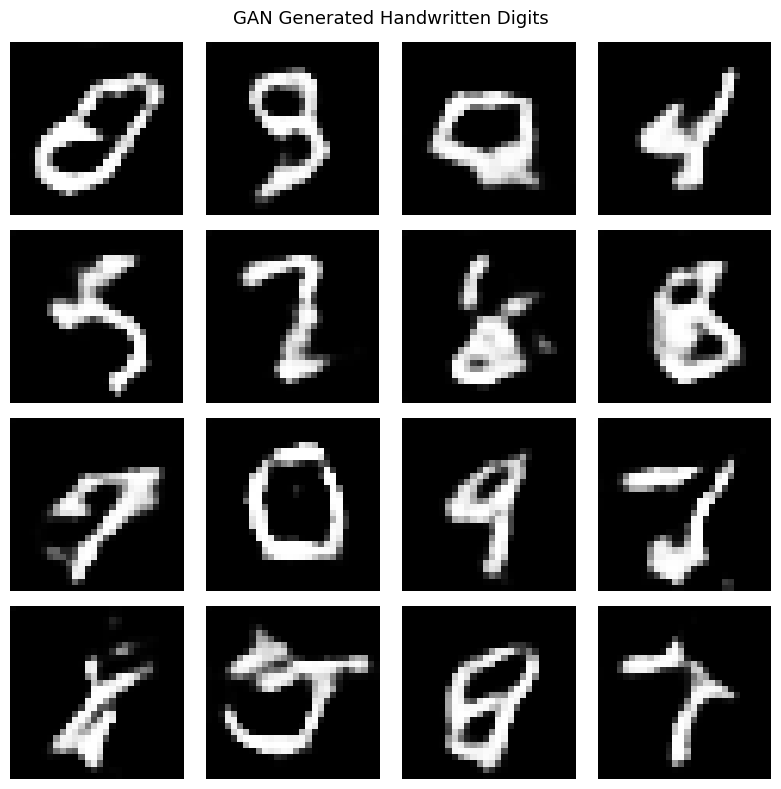

In [ ]:

noise = tf.random.normal([16, NOISE_DIM])
generated = generator(noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(generated[i, :, :, 0] * 127.5 + 127.5, cmap='gray')  # [-1,1] → [0,255]
    plt.axis('off')

plt.suptitle('GAN Generated Handwritten Digits', fontsize=13)
plt.tight_layout()
plt.show()

## Real vs Fake Comparison

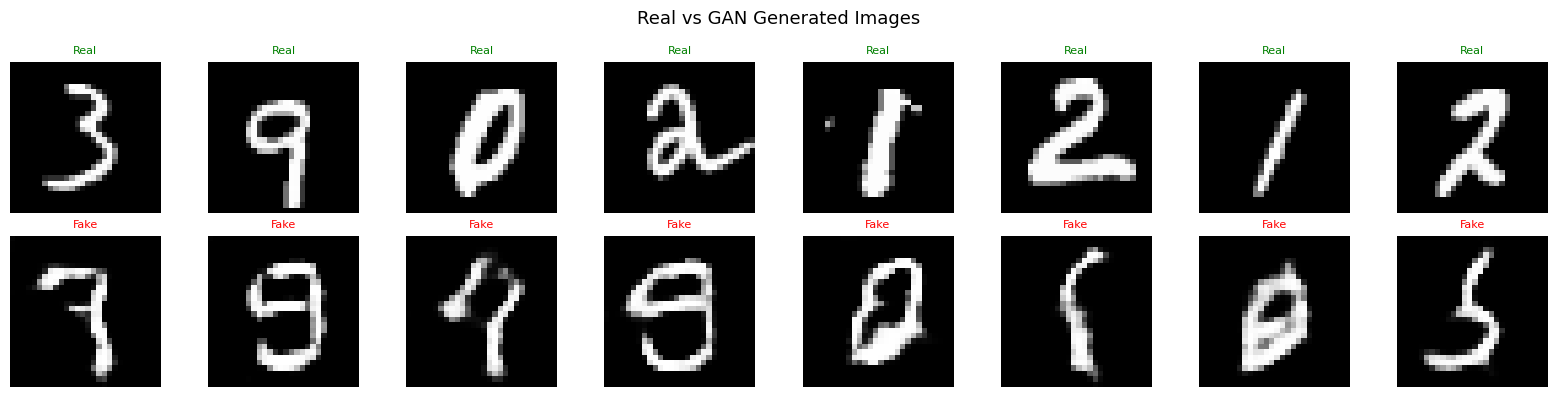

In [ ]:
# Real images
real_indices = np.random.choice(len(X_train), 8, replace=False)
real_samples = X_train[real_indices]

# Fake images 
noise = tf.random.normal([8, NOISE_DIM])
fake_samples = generator(noise, training=False).numpy()

plt.figure(figsize=(16, 4))

# Real images — top row
for i in range(8):
    plt.subplot(2, 8, i+1)
    plt.imshow(real_samples[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.title('Real', fontsize=8, color='green')
    plt.axis('off')

# Fake images — bottom row
for i in range(8):
    plt.subplot(2, 8, i+9)
    plt.imshow(fake_samples[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.title('Fake', fontsize=8, color='red')
    plt.axis('off')

plt.suptitle('Real vs GAN Generated Images', fontsize=13)
plt.tight_layout()
plt.show()